In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [ ]:
full_df = pd.read_csv("airbnb-listings-extract.csv", sep=';')
train, test = train_test_split(full_df, test_size=0.2, shuffle=True, random_state=0)

print(f'Dimensiones del dataset de training: {train.shape}')
print(f'Dimensiones del dataset de test: {test.shape}')

# Guardamos
train.to_csv('airbnb_train.csv', sep=';', decimal='.', index=False)
test.to_csv('airbnb_test.csv', sep=';', decimal='.', index=False)

# Cargamos el dataset de train y trabajamos ÚNICAMENTE con él.

airbnb_train = pd.read_csv('airbnb_train.csv', sep=';', decimal='.')
display(airbnb_train.head(5).T)

Dimensiones del dataset de training: (11824, 89)
Dimensiones del dataset de test: (2956, 89)


,0,1,2,3,4
ID,5994463,14136180,15520134,8809721,1162707
Listing Url,https://www.airbnb.com/rooms/5994463,https://www.airbnb.com/rooms/14136180,https://www.airbnb.com/rooms/15520134,https://www.airbnb.com/rooms/8809721,https://www.airbnb.com/rooms/1162707
Scrape ID,20170407214119,20170407214119,20170407214119,20170407214119,20170407214119
Last Scraped,2017-04-08,2017-04-08,2017-04-08,2017-04-08,2017-04-08
Name,PISO ATOCHA- FLAT NEAR ATOCHA .,The Palace Sol Madrid.,por persona la noche metro linea5 vista alegre,CITY CENTER JACINTO BENAVENTE ROOM4,NICE & BIG DOUBLE ROOM AT DOWNTOWN
...,...,...,...,...,...
Cancellation Policy,moderate,flexible,moderate,strict,strict
Calculated host listings count,2.0,1.0,16.0,97.0,2.0
Reviews per Month,0.5,2.43,NaN,NaN,2.08
Geolocation,"40.4077318793,-3.68481869733","40.4158022422,-3.70534037765","40.3890481626,-3.74037392557","40.4128140929,-3.70305247638","40.4386311984,-3.71371613279"


In [ ]:
airbnb_train.describe()

,ID,Scrape ID,Host ID,Host Response Rate,Host Listings Count,Host Total Listings Count,Latitude,Longitude,Accommodates,Bathrooms,...,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month
count,1.182400e+04,1.182400e+04,1.182400e+04,10317.000000,11821.000000,11821.000000,11824.000000,11824.000000,11824.000000,11780.000000,...,11824.000000,9163.000000,9143.000000,9148.000000,9136.000000,9147.000000,9133.000000,9132.000000,11820.000000,9285.000000
mean,1.025308e+07,2.017038e+13,3.588310e+07,94.803722,12.754420,12.754420,40.491628,-3.776863,3.277486,1.285229,...,22.664834,91.628179,9.410040,9.320726,9.623905,9.647863,9.534655,9.211345,9.615313,1.873326
std,5.566485e+06,5.505346e+08,3.411993e+07,15.247078,34.578895,34.578895,4.701030,14.014695,2.093973,0.664691,...,38.092338,9.137614,0.938013,1.004472,0.804050,0.765450,0.770421,0.963131,23.795580,1.869157
min,1.986400e+04,2.016010e+13,1.745300e+04,0.000000,0.000000,0.000000,-37.851182,-123.124429,1.000000,0.000000,...,0.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.020000
25%,5.510692e+06,2.017041e+13,6.855490e+06,100.000000,1.000000,1.000000,40.409758,-3.707538,2.000000,1.000000,...,1.000000,89.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,1.000000,0.450000
50%,1.125754e+07,2.017041e+13,2.454770e+07,100.000000,2.000000,2.000000,40.419331,-3.700763,3.000000,1.000000,...,7.000000,94.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,2.000000,1.210000
75%,1.531982e+07,2.017041e+13,5.431096e+07,100.000000,6.000000,6.000000,40.430778,-3.683917,4.000000,1.000000,...,27.000000,98.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,5.000000,2.780000
max,1.858361e+07,2.017062e+13,1.247534e+08,100.000000,519.000000,519.000000,55.966912,153.371427,16.000000,8.000000,...,356.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,145.000000,17.210000


In [ ]:
airbnb_train.isnull().any()

,0
ID,False
Listing Url,False
Scrape ID,False
Last Scraped,False
Name,True
...,...
Cancellation Policy,False
Calculated host listings count,True
Reviews per Month,True
Geolocation,False


In [ ]:
conteo_nulos = airbnb_train.isnull().sum()

In [ ]:
print(conteo_nulos[conteo_nulos > 0])

Name                                  1
Summary                             469
Space                              3106
Description                           6
Neighborhood Overview              4515
Notes                              7281
Transit                            4581
Access                             5161
Interaction                        5232
House Rules                        4143
Thumbnail Url                      2295
Medium Url                         2295
Picture Url                          18
XL Picture Url                     2295
Host Name                             3
Host Since                            3
Host Location                        34
Host About                         4160
Host Response Time                 1507
Host Response Rate                 1507
Host Acceptance Rate              11794
Host Thumbnail Url                    3
Host Picture Url                      3
Host Neighbourhood                 3082
Host Listings Count                   3


In [ ]:
with pd.option_context('display.max_rows', None):
    print(airbnb_train.dtypes)

ID                                  int64
Listing Url                        object
Scrape ID                           int64
Last Scraped                       object
Name                               object
Summary                            object
Space                              object
Description                        object
Experiences Offered                object
Neighborhood Overview              object
Notes                              object
Transit                            object
Access                             object
Interaction                        object
House Rules                        object
Thumbnail Url                      object
Medium Url                         object
Picture Url                        object
XL Picture Url                     object
Host ID                             int64
Host URL                           object
Host Name                          object
Host Since                         object
Host Location                     

In [ ]:
conteo_ciudades = airbnb_train['City'].value_counts()
print(conteo_ciudades)

City
Madrid              10567
Barcelona             235
London                104
Paris                  85
Palma                  44
                    ...  
Hong Kong               1
San Fernando            1
Tsim Sha Tsui           1
Beverly Hills           1
Aravaca (Madrid)        1
Name: count, Length: 222, dtype: int64


Decidimos quedarnos solo con Madrid ya que la mayoria de datos proceden de allí


In [ ]:
# 1. Filtramos
airbnb_madrid = airbnb_train[airbnb_train['City'].str.strip() == 'Madrid'].copy()

# 2. Columnas a descartar
columnas_a_descartar = [
    'Name', 'Summary', 'Space', 'Description', 'Neighborhood Overview', 'Notes',
    'Transit', 'Access', 'Interaction', 'House Rules', 'Thumbnail Url', 'Medium Url',
    'Picture Url', 'XL Picture Url', 'Host Name', 'Host Since', 'Host Location',
    'Host About', 'Host Response Time', 'Host Response Rate', 'Host Acceptance Rate',
    'Host Thumbnail Url', 'Host Picture Url', 'Host Neighbourhood', 'Host Listings Count',
    'Host Total Listings Count', 'Host Verifications', 'Neighbourhood', 'Beds',
    'Amenities', 'Weekly Price', 'Monthly Price', 'Security Deposit', 'Cleaning Fee',
    'Has Availability', 'First Review', 'Last Review', 'Review Scores Rating',
    'Review Scores Accuracy', 'Review Scores Cleanliness', 'Review Scores Checkin',
    'Review Scores Communication', 'Review Scores Location', 'Review Scores Value',
    'License', 'Jurisdiction Names', 'Calculated host listings count', 'Reviews per Month',
    'ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Experiences Offered',
    'Host ID', 'Host URL', 'Street', 'Neighbourhood Cleansed', 'State',
    'Zipcode', 'Market', 'Smart Location', 'Country Code', 'Country',
    'Accommodates', 'Guests Included', 'Extra People', 'Minimum Nights',
    'Maximum Nights', 'Calendar Updated', 'Availability 30', 'Availability 60',
    'Availability 90', 'Availability 365', 'Calendar last Scraped',
    'Number of Reviews', 'Cancellation Policy', 'Property Type', 'Bed Type', 'Geolocation', 'Features', 'Square Feet'
]

# 3. Eliminamos las columnas selecionadas
airbnb_madrid_final = airbnb_madrid.drop(columns=columnas_a_descartar, axis=1, errors='ignore')

# 4. Comprobamos
print(airbnb_madrid_final.dtypes)

Neighbourhood Group Cleansed     object
City                             object
Latitude                        float64
Longitude                       float64
Room Type                        object
Bathrooms                       float64
Bedrooms                        float64
Price                           float64
dtype: object


In [ ]:
# 1. Calculamos la moda
moda_bathrooms = airbnb_madrid_final['Bathrooms'].mode()[0]
moda_bedrooms = airbnb_madrid_final['Bedrooms'].mode()[0]

# 2. Rellenamos los valores nulos
airbnb_madrid_final['Bathrooms'] = airbnb_madrid_final['Bathrooms'].fillna(moda_bathrooms)
airbnb_madrid_final['Bedrooms'] = airbnb_madrid_final['Bedrooms'].fillna(moda_bedrooms)

# 3. Comprobamos
print("Nulos restantes:")
print(airbnb_madrid_final[['Bathrooms', 'Bedrooms']].isnull().sum())

Nulos restantes:
Bathrooms    0
Bedrooms     0
dtype: int64


In [ ]:
medias_por_distrito = airbnb_madrid_final.groupby('Neighbourhood Group Cleansed')['Price'].mean()
print(medias_por_distrito)

Neighbourhood Group Cleansed
Arganzuela               46.149371
Barajas                  53.106061
Carabanchel              39.895105
Centro                   72.848412
Chamartín                74.917563
Chamberí                 72.247706
Ciudad Lineal            44.843621
Fuencarral - El Pardo    55.052632
Hortaleza                50.000000
Latina                   34.218430
Moncloa - Aravaca        66.011976
Moratalaz                38.032787
Puente de Vallecas       39.242604
Retiro                   70.172316
Salamanca                86.192737
San Blas - Canillejas    37.911111
Tetuán                   54.272727
Usera                    40.000000
Vicálvaro                37.407407
Villa de Vallecas        42.918919
Villaverde               34.644068
Name: Price, dtype: float64


In [ ]:
# Reemplazamos los textos de los barrios por sus respectivas medias numéricas
airbnb_madrid_final['Neighbourhood Group Cleansed'] = airbnb_madrid_final['Neighbourhood Group Cleansed'].map(medias_por_distrito)

In [ ]:
medias_por_habitacion = airbnb_madrid_final.groupby('Room Type')['Price'].mean()
print(medias_por_habitacion)

Room Type
Entire home/apt    87.633318
Private room       34.262913
Shared room        30.129252
Name: Price, dtype: float64


In [ ]:
print(airbnb_madrid_final['Room Type'].value_counts())

Room Type
Entire home/apt    6333
Private room       4087
Shared room         147
Name: count, dtype: int64


In [ ]:
# 1. Calculamos las medias de precio por cada tipo de habitación
mean_room_type = airbnb_madrid_final.groupby('Room Type')['Price'].mean()

# 2. Reemplazamos
airbnb_madrid_final['Room Type'] = airbnb_madrid_final['Room Type'].map(mean_room_type)

# 3. Comprobamos
print(airbnb_madrid_final['Room Type'].head())

0    87.633318
1    87.633318
2    30.129252
3    34.262913
4    34.262913
Name: Room Type, dtype: float64


In [ ]:
print(airbnb_madrid_final.isnull().sum())

Neighbourhood Group Cleansed    0
City                            0
Latitude                        0
Longitude                       0
Room Type                       0
Bathrooms                       0
Bedrooms                        0
Price                           8
dtype: int64


In [ ]:
# 1. Calculamos la media de la columna Price
media_precio = airbnb_madrid_final['Price'].mean()
print(f"El precio medio en Madrid es: {media_precio:.2f} €")

# 2. Rellenamos
airbnb_madrid_final['Price'] = airbnb_madrid_final['Price'].fillna(media_precio)

# 3. Comprobamos
print(f"Valores nulos restantes en Price: {airbnb_madrid_final['Price'].isnull().sum()}")

El precio medio en Madrid es: 66.19 €
Valores nulos restantes en Price: 0


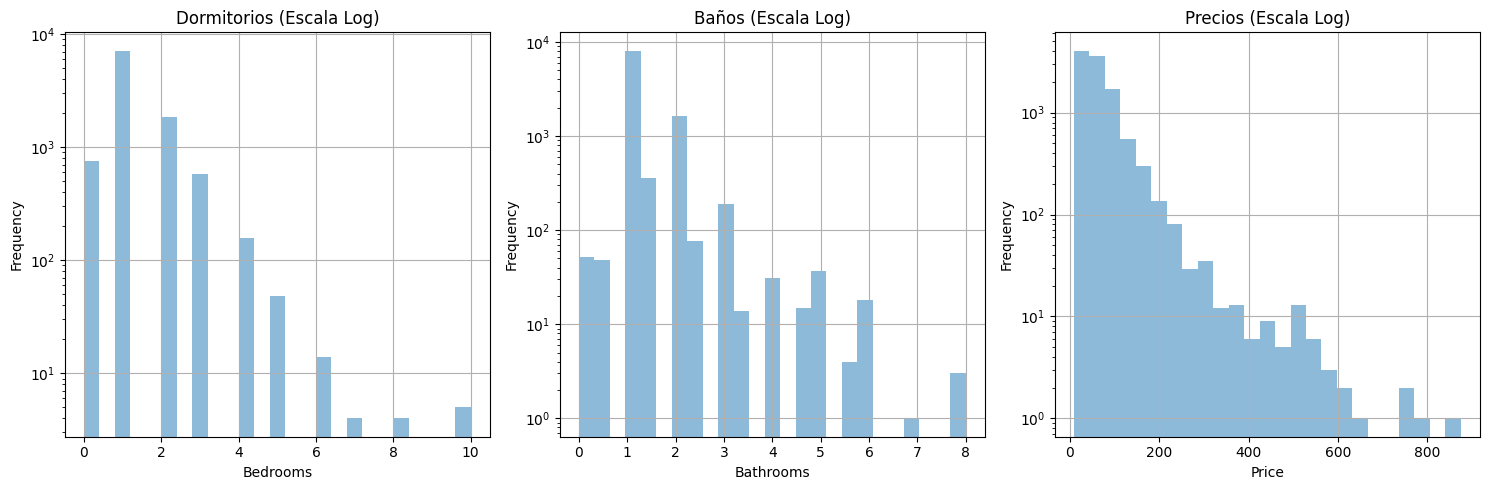

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# 1. Bedrooms con escala logarítmica
plt.subplot(1, 3, 1)
airbnb_madrid_final['Bedrooms'].plot.hist(alpha=0.5, bins=25, grid=True)
plt.yscale("log")
plt.xlabel('Bedrooms')
plt.title('Dormitorios (Escala Log)')

# 2. Bathrooms con escala logarítmica
plt.subplot(1, 3, 2)
airbnb_madrid_final['Bathrooms'].plot.hist(alpha=0.5, bins=25, grid=True)
plt.yscale("log")
plt.xlabel('Bathrooms')
plt.title('Baños (Escala Log)')

# 3. Price con escala logarítmica
plt.subplot(1, 3, 3)
airbnb_madrid_final['Price'].plot.hist(alpha=0.5, bins=25, grid=True)
plt.yscale("log")
plt.xlabel('Price')
plt.title('Precios (Escala Log)')

plt.tight_layout()
plt.show()

In [ ]:
filas_antes = airbnb_madrid_final.shape[0]

# Aplicamos corte de outliers
airbnb_madrid_final = airbnb_madrid_final[
    (airbnb_madrid_final['Bedrooms'] <= 6) &
    (airbnb_madrid_final['Bathrooms'] <= 6) &
    (airbnb_madrid_final['Price'] <= 600)
]

filas_despues = airbnb_madrid_final.shape[0]


print(f"Dataset original: {filas_antes} filas.")
print(f"Dataset limpio actual: {filas_despues} filas.")

Dataset original: 10567 filas.
Dataset limpio actual: 10548 filas.


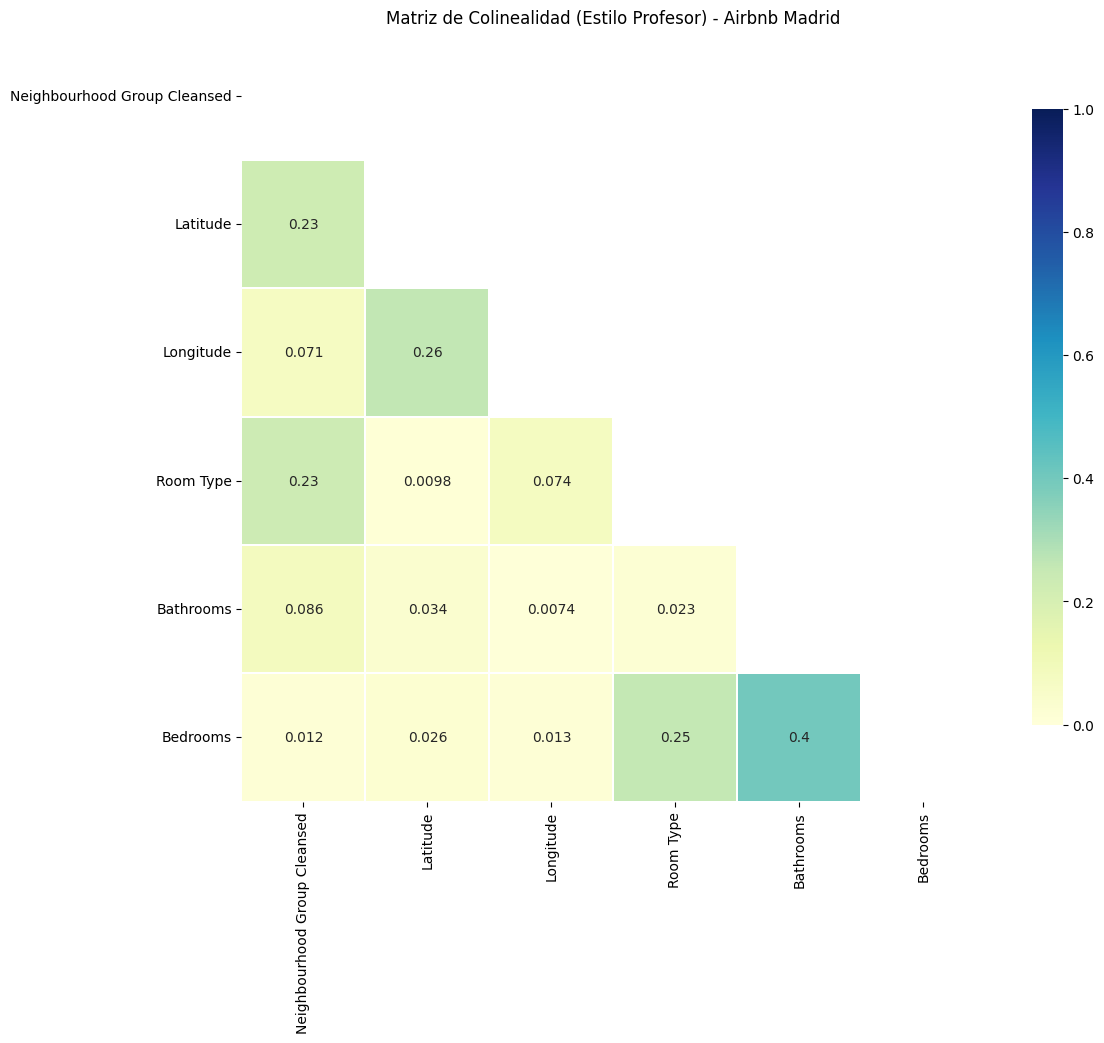

In [ ]:
# 1. Calculamos la matriz de correlación en valor absoluto SIN'Price'
corr = np.abs(airbnb_madrid_final.drop(['Price'], axis=1).corr(numeric_only=True))

# 2. Vemos el triangulo de abajo
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# 3. Configuramos el lienzo
f, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, vmin=0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8}, annot=True)

plt.title('Matriz de Colinealidad')
plt.show()

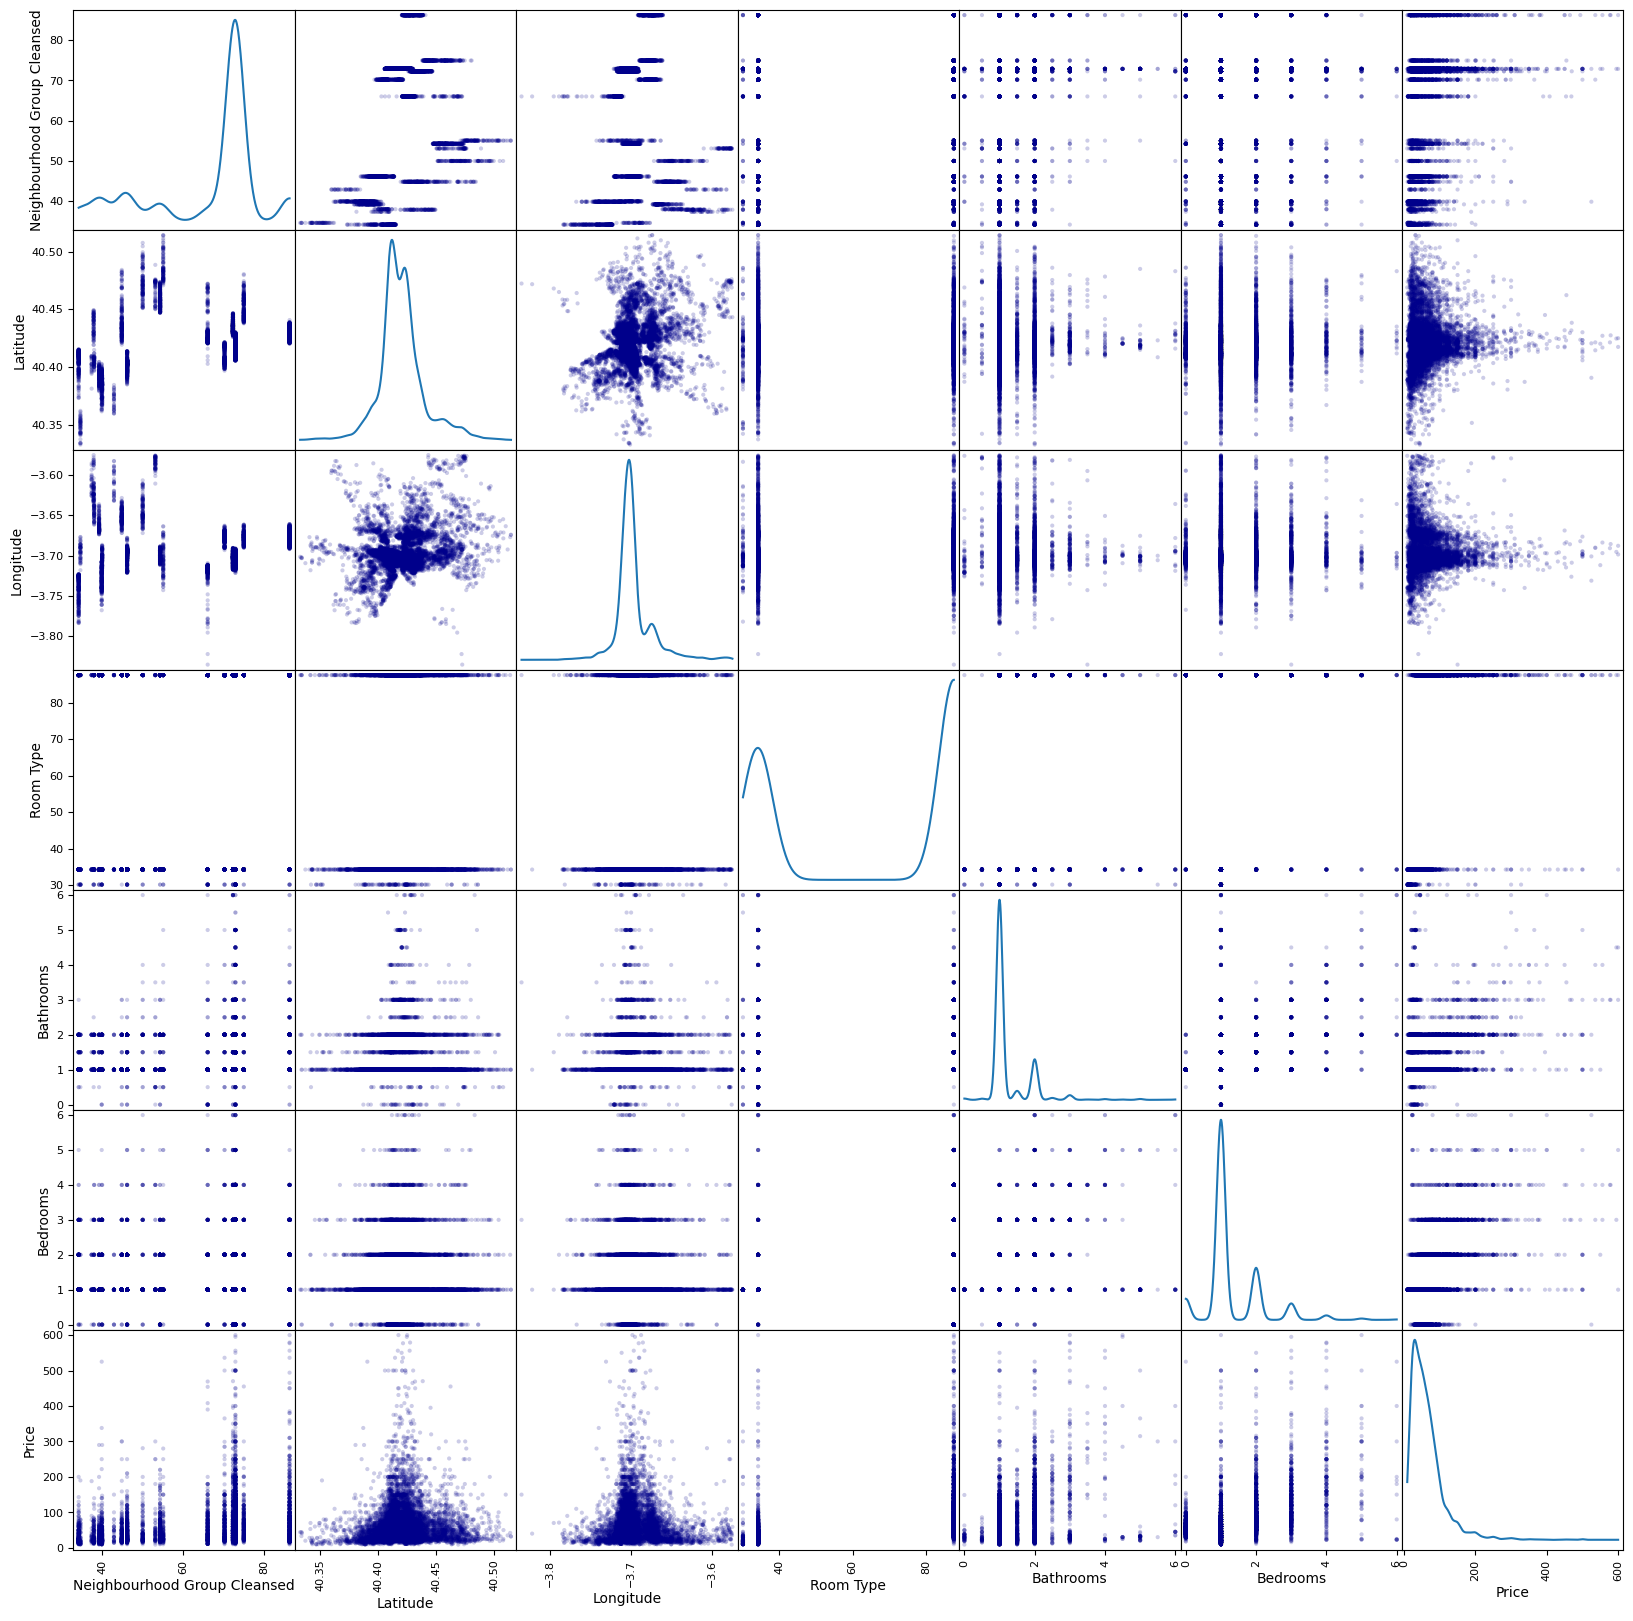

In [ ]:
pd.plotting.scatter_matrix(
    airbnb_madrid_final,
    alpha=0.2,
    figsize=(20, 20),
    diagonal='kde',
    color='darkblue'
)

plt.show()

In [ ]:

# 1. Capturamos la relación entre dormitorios y baños
airbnb_madrid_final['bed_bath_rooms']   = airbnb_madrid_final['Bedrooms']*airbnb_madrid_final['Bathrooms']
# Comprobamos
print(airbnb_madrid_final[['Bedrooms', 'Bathrooms', 'bed_bath_rooms']].head())

   Bedrooms  Bathrooms  bed_bath_rooms
0       1.0        1.0             1.0
1       1.0        1.0             1.0
2       1.0        1.5             1.5
3       1.0        3.0             3.0
4       1.0        1.0             1.0


In [ ]:
# 1. Carga de datos
airbnb_train = pd.read_csv('airbnb_train.csv', sep=';', decimal='.')

# 2. Filtrado inicial por Madrid
is_madrid = airbnb_train['City'].fillna('').str.strip() == 'Madrid'
airbnb_madrid = airbnb_train[is_madrid].copy()

# 3. Imputación
moda_bathrooms = airbnb_madrid['Bathrooms'].mode()[0]
moda_bedrooms = airbnb_madrid['Bedrooms'].mode()[0]
media_precio = airbnb_madrid['Price'].mean()

airbnb_madrid['Bathrooms'].fillna(moda_bathrooms, inplace=True)
airbnb_madrid['Bedrooms'].fillna(moda_bedrooms, inplace=True)
airbnb_madrid['Price'].fillna(media_precio, inplace=True)

# 4. Eliminamos columnas
columnas_a_descartar = [
    'Name', 'Summary', 'Space', 'Description', 'Neighborhood Overview', 'Notes',
    'Transit', 'Access', 'Interaction', 'House Rules', 'Thumbnail Url', 'Medium Url',
    'Picture Url', 'XL Picture Url', 'Host Name', 'Host Since', 'Host Location',
    'Host About', 'Host Response Time', 'Host Response Rate', 'Host Acceptance Rate',
    'Host Thumbnail Url', 'Host Picture Url', 'Host Neighbourhood', 'Host Listings Count',
    'Host Total Listings Count', 'Host Verifications', 'Neighbourhood', 'Beds',
    'Amenities', 'Weekly Price', 'Monthly Price', 'Security Deposit', 'Cleaning Fee',
    'Has Availability', 'First Review', 'Last Review', 'Review Scores Rating',
    'Review Scores Accuracy', 'Review Scores Cleanliness', 'Review Scores Checkin',
    'Review Scores Communication', 'Review Scores Location', 'Review Scores Value',
    'License', 'Jurisdiction Names', 'Calculated host listings count', 'Reviews per Month',
    'ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Experiences Offered',
    'Host ID', 'Host URL', 'Street', 'Neighbourhood Cleansed', 'State',
    'Zipcode', 'Market', 'Smart Location', 'Country Code', 'Country',
    'Accommodates', 'Guests Included', 'Extra People', 'Minimum Nights',
    'Maximum Nights', 'Calendar Updated', 'Availability 30', 'Availability 60',
    'Availability 90', 'Availability 365', 'Calendar last Scraped',
    'Number of Reviews', 'Cancellation Policy', 'Property Type', 'Bed Type', 'Geolocation', 'Features', 'Square Feet', 'City'
]

airbnb_madrid_final = airbnb_madrid.drop(columns=columnas_a_descartar, axis=1, errors='ignore')

# 5. Target Encoding
medias_por_distrito = airbnb_madrid_final.groupby('Neighbourhood Group Cleansed')['Price'].mean()
airbnb_madrid_final['Neighbourhood Group Cleansed'] = airbnb_madrid_final['Neighbourhood Group Cleansed'].map(medias_por_distrito)

mean_room_type = airbnb_madrid_final.groupby('Room Type')['Price'].mean()
airbnb_madrid_final['Room Type'] = airbnb_madrid_final['Room Type'].map(mean_room_type)

# 6. Eliminamos outliers
airbnb_madrid_final = airbnb_madrid_final[
    (airbnb_madrid_final['Bedrooms'] <= 6) &
    (airbnb_madrid_final['Bathrooms'] <= 6) &
    (airbnb_madrid_final['Price'] <= 600)
]

# 7. Generamos características
airbnb_madrid_final['bed_bath_rooms'] = airbnb_madrid_final['Bedrooms'] * airbnb_madrid_final['Bathrooms']


# =====================================================================
# (TEST)
# =====================================================================

# Carga de datos de TEST
airbnb_test = pd.read_csv('airbnb_test.csv', sep=';', decimal='.')

# Filtrado por Madrid
is_madrid_test = airbnb_test['City'].fillna('').str.strip() == 'Madrid'
airbnb_madrid_test = airbnb_test[is_madrid_test].copy()

# Imputación
airbnb_madrid_test['Bathrooms'].fillna(airbnb_madrid_test['Bathrooms'].mode()[0], inplace=True)
airbnb_madrid_test['Bedrooms'].fillna(airbnb_madrid_test['Bedrooms'].mode()[0], inplace=True)
airbnb_madrid_test['Price'].fillna(airbnb_madrid_test['Price'].mean(), inplace=True)

# Eliminamos las columnas
airbnb_madrid_final_test = airbnb_madrid_test.drop(columns=columnas_a_descartar, axis=1, errors='ignore')

# Target Encoding
medias_por_distrito_test = airbnb_madrid_final_test.groupby('Neighbourhood Group Cleansed')['Price'].mean()
airbnb_madrid_final_test['Neighbourhood Group Cleansed'] = airbnb_madrid_final_test['Neighbourhood Group Cleansed'].map(medias_por_distrito_test)

mean_room_type_test = airbnb_madrid_final_test.groupby('Room Type')['Price'].mean()
airbnb_madrid_final_test['Room Type'] = airbnb_madrid_final_test['Room Type'].map(mean_room_type_test)

# Eliminamos outliers
airbnb_madrid_final_test = airbnb_madrid_final_test[
    (airbnb_madrid_final_test['Bedrooms'] <= 6) &
    (airbnb_madrid_final_test['Bathrooms'] <= 6) &
    (airbnb_madrid_final_test['Price'] <= 600)
]

# Generamos características
airbnb_madrid_final_test['bed_bath_rooms'] = airbnb_madrid_final_test['Bedrooms'] * airbnb_madrid_final_test['Bathrooms']

In [ ]:
y_train = airbnb_madrid_final[['Price']].values
X_train = airbnb_madrid_final.drop(columns=['Price']).values

y_test = airbnb_madrid_final_test[['Price']].values
X_test = airbnb_madrid_final_test.drop(columns=['Price']).values

scaler = preprocessing.StandardScaler().fit(X_train)
XtrainScaled = scaler.transform(X_train)
XtestScaled = scaler.transform(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................alpha=0.37926901907322497; total time=   0.0s
[CV] END ..........................alpha=0.37926901907322497; total time=   0.0s
[CV] END ..........................alpha=0.37926901907322497; total time=   0.0s
[CV] END ..........................alpha=0.37926901907322497; total time=   0.0s
[CV] END ..........................alpha=0.37926901907322497; total time=   0.0s
[CV] END ............................alpha=1.438449888287663; total time=   0.0s
[CV] END ............................alpha=1.43

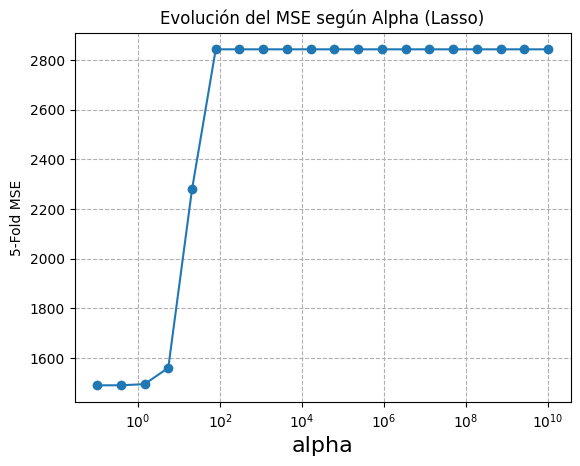

In [ ]:
alpha_vector = np.logspace(-1, 10, 20)
param_grid = {'alpha': alpha_vector}

grid = GridSearchCV(Lasso(), scoring='neg_mean_squared_error', param_grid=param_grid, cv=5, verbose=2)
grid.fit(XtrainScaled, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = -1 * np.array(grid.cv_results_['mean_test_score'])

plt.semilogx(alpha_vector, scores, '-o')
plt.xlabel('alpha', fontsize=16)
plt.ylabel('5-Fold MSE')
plt.title('Evolución del MSE según Alpha (Lasso)')
plt.grid(True, which="both", ls="--")
plt.show()

In [ ]:
alpha_optimo = grid.best_params_['alpha']
lasso = Lasso(alpha=alpha_optimo).fit(XtrainScaled, y_train)

ytrainLasso = lasso.predict(XtrainScaled)
ytestLasso = lasso.predict(XtestScaled)

mseTrainModelLasso = mean_squared_error(y_train, ytrainLasso)
mseTestModelLasso = mean_squared_error(y_test, ytestLasso)

print('MSE Modelo Lasso (train): %0.3g' % mseTrainModelLasso)
print('MSE Modelo Lasso (test) : %0.3g' % mseTestModelLasso)
print('RMSE Modelo Lasso (train): %0.3g' % np.sqrt(mseTrainModelLasso))
print('RMSE Modelo Lasso (test) : %0.3g' % np.sqrt(mseTestModelLasso))

feature_names = airbnb_madrid_final.drop(columns=['Price']).columns

w = lasso.coef_
print("\n--- Coeficientes del Modelo Lasso ---")
for f, wi in zip(feature_names, w):
    print(f, wi)

MSE Modelo Lasso (train): 1.49e+03
MSE Modelo Lasso (test) : 1.33e+03
RMSE Modelo Lasso (train): 38.6
RMSE Modelo Lasso (test) : 36.5

--- Coeficientes del Modelo Lasso ---
Neighbourhood Group Cleansed 7.544724768510909
Latitude 0.14039940066602088
Longitude 0.0
Room Type 19.185744709142273
Bathrooms -0.8481533749831872
Bedrooms 3.2069469000486337
bed_bath_rooms 23.26396425974778


El modelo Lasso muestra una buena capacidad de generalización al mantener un error similar entre los datos de entrenamiento y prueba. Variables espaciales como el tamaño de la vivienda (bed_bath_rooms) y el tipo de habitación resultan determinantes para fijar el precio en Madrid, aunque el error absoluto final sugiere que un modelo lineal se queda corto para capturar la complejidad y los matices cualitativos del mercado inmobiliario.